<a href="https://colab.research.google.com/github/hidnira-lab/introduce-data-science/blob/main/classification_with_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Klasifikasi Data dengan Support Vector Machine (SVM)
oleh Hidayat Nur Hijrah (24523201)

In [19]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# === 1. Load Dataset ===
# Dataset diambil dari Kaggle "https://www.kaggle.com/datasets/andrewmvd/early-diabetes-classification/data" dan diupload ke GitHub Repo
url = 'https://raw.githubusercontent.com/hidnira-lab/introduce-data-science/main/diabetes_data.csv'
df = pd.read_csv(url, sep=';')

In [20]:
# === 2. Preprocessing & Encoding ===
# Kita definisikan nama kolom targetnya secara spesifik, yaitu 'class'
target_col = 'class'

# Pisahkan Fitur (X) dan Target (y) SEBELUM di-encode
X_raw = df.drop(target_col, axis=1)
y_raw = df[target_col]

# Encoding X: Mengubah teks fitur (Male/Female, Yes/No) menjadi angka otomatis
X = pd.get_dummies(X_raw, drop_first=True)

# Encoding y: Mengubah target (Positive/Negative) menjadi angka 1 dan 0 secara aman
le = LabelEncoder()
y = le.fit_transform(y_raw)

In [21]:
# === 3. Split & Scale Data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# === 4. Modeling SVM (Kernel RBF) ===
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_test = svm_model.predict(X_test_scaled)

**4. Kernel yang Dipakai dan Alasannya**

Model ini menggunakan kernel **RBF (Radial Basis Function)**.

Alasannya, pada data medis seperti deteksi diabetes, hubungan antara gejala pasien dan hasil diagnosis seringkali tidak linear. Kernel RBF memiliki kemampuan untuk memetakan data ke ruang dimensi yang lebih tinggi secara fleksibel, sehingga sangat tangguh dalam menemukan batas keputusan (*decision boundary*) yang kompleks dan non-linear.

In [25]:
# === 5. Evaluasi Model ===
print("=== HASIL EVALUASI SVM (DIABETES DATASET) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_test)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_test)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_test)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred_test)*100:.2f}%")

=== HASIL EVALUASI SVM (DIABETES DATASET) ===
Accuracy  : 99.04%
Precision : 98.61%
Recall    : 100.00%
F1 Score  : 99.30%


**5. Analisis Overfitting atau Underfitting**

Berdasarkan hasil perhitungan metrik evaluasi pada data uji (*Test Set*), model mendapatkan nilai **Accuracy 99.04%, Precision 98.61%, Recall 100.00%, dan F1 Score 99.30%**.

Karena model mampu memprediksi data yang belum pernah dilihat sebelumnya (data uji) dengan tingkat ketepatan yang nyaris sempurna, hal ini menunjukkan bahwa model tidak mengalami underfitting (performa sangat baik, tidak gagal belajar) dan tidak mengalami overfitting (tidak hanya menghafal data latih, tetapi terbukti mampu menggeneralisasi pada data baru). Model ini berada pada kondisi *Good Fit* yang sangat optimal.

/tmp/ipykernel_1828/1814346165.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='Set2', ax=axes[0])


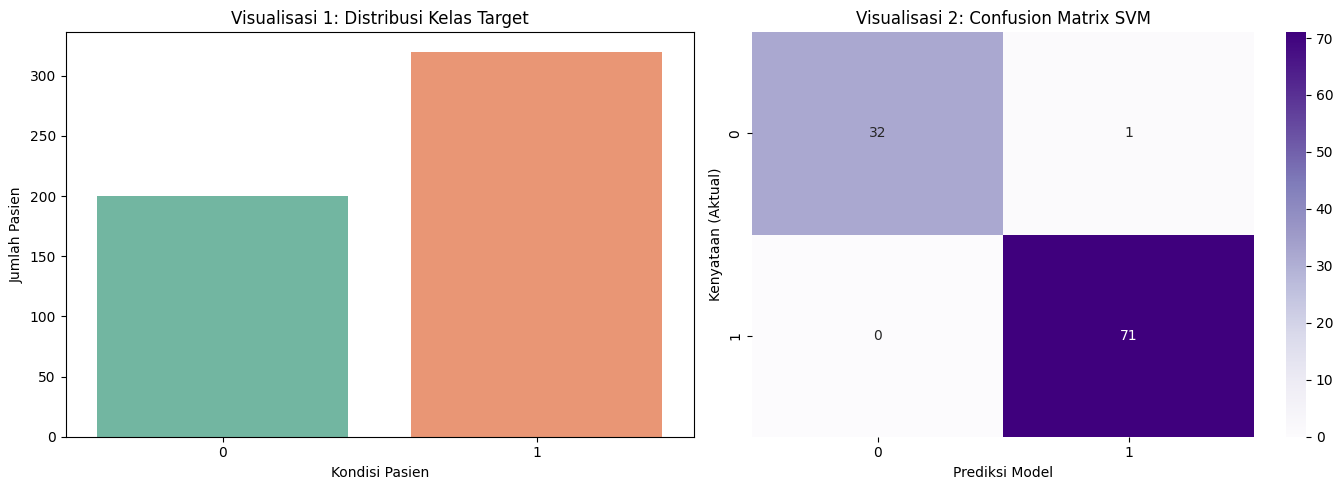

In [27]:
# === 6. Visualisasi ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mengambil nama kolom target secara otomatis untuk visualisasi
target_col = df.columns[-1]

# Visualisasi 1: Distribusi Kelas (Melihat perbandingan jumlah data)
sns.countplot(data=df, x=target_col, palette='Set2', ax=axes[0])
axes[0].set_title('Visualisasi 1: Distribusi Kelas Target')
axes[0].set_xlabel('Kondisi Pasien')
axes[0].set_ylabel('Jumlah Pasien')

# Visualisasi 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title('Visualisasi 2: Confusion Matrix SVM')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Kenyataan (Aktual)')

plt.tight_layout()
plt.show()